In [1]:
# -*- coding: utf-8 -*-
from math import radians, degrees, sin, cos, tan, sqrt, atan, exp, pi, asin
from scipy.stats import t
import numpy as np
import matplotlib.pyplot as plt
import itertools

In [3]:
# -----------------------
# INPUTS
# -----------------------
a = 1.0        # strip foundation length (per unit length ok) 
b = 2.5        # foundation width
D = 1.2        # embedment depth
foundation = "strip"
gamma_soil = 19    # unit weight
phi_mean = 30      # friction angle [deg]
c_mean = 0         # cohesion [kPa or kN/m²]
V_G = 600          # permanent vertical load [kN]
H_Q = 0            # external horizontal load (e.g., wind) [kN]

# Characteristic value parameters
phi_cov = 0.1      # coefficient of variation for phi
c_cov = 0.4        # coefficient of variation for cohesion
phi_theta = 5      # scale of fluctuation for phi [m]
c_theta = 5        # scale of fluctuation for cohesion [m]
Case = "2"         # "1", "2", or "3" for characteristic value calculation
n = 30             # number of samples for t-distribution
alpha_4017 = 0     # wall inclination angle for DIN 4017 [deg]
beta_4017 = 0      # backfill angle for DIN 4017 [deg]

# Partial factors 
gamma_Rv = 1.4     # on resistance
gamma_N = 1.35     # on vertical load (here only G present)

# --- Variables to Plot ---
theta_values = np.linspace(0.1, 50.0, 50)  # Scale of fluctuation range [m]
D_values = [0, 0.5, 1.2, 1.5]             # Embedment depths to compare [m]
colors = ['b', 'r']                       # Colors for each D
line_styles = ['-', '--']                 # Line styles

# Switches to include effects
USE_ACTIVE = False
USE_PASSIVE = False

# ==========================================================
# Utilities / guards
# ==========================================================
def _clip_sin_arg(x: float) -> float:
    return max(-1.0, min(1.0, x))

def _nz(x: float, eps: float = 1e-12) -> float:
    return x if abs(x) > eps else (eps if x >= 0.0 else -eps)

# ==========================================================
# Bearing capacity coefficients (Terzaghi/Meyerhof-type)
# ==========================================================
def bearing_capacity_coeffs(phi_deg: float):
    phi = radians(phi_deg)
    Nd0 = (tan(radians(45.0) + phi / 2.0) ** 2) * exp(pi * tan(phi))
    Nb0 = (Nd0 - 1.0) * tan(phi)
    Nc0 = (Nd0 - 1.0) / tan(phi)
    return Nd0, Nb0, Nc0

# ==========================================================
# Active pressure (with cohesion) — guarded
# ==========================================================
def active_pressure(phi_deg, c_k, gamma, H, alpha=0.0, beta=0.0, phi_min=None):
    if phi_min is None:
        phi_min = phi_deg  # do not force a minimum unless desired
    delta = (2.0 / 3.0) * phi_deg

    # K_agh
    num  = cos(radians(phi_deg - alpha))
    den1 = cos(radians(alpha))
    sin_part = sin(radians(phi_deg + delta)) * sin(radians(phi_deg - beta))
    cos_part = cos(radians(alpha - beta)) * cos(radians(alpha + delta))
    ratio = max(1e-12, sin_part / _nz(cos_part))
    den2 = sqrt(ratio)
    K_agh = (num / (den1 * (1.0 + den2))) ** 2

    # K_ach
    K_ach = (2.0 * cos(radians(alpha - beta)) * cos(radians(phi_deg)) * cos(radians(alpha + delta))) / \
            _nz(1.0 + sin(radians(phi_deg + delta + alpha - beta)) * cos(radians(alpha)))

    # base stress
    e_ach = -c_k * K_ach
    e_agh = gamma * H * K_agh
    e_ah  = e_agh + e_ach

    # cohesion cutoff height
    z_start = 0.0
    if K_agh > 0.0:
        z_start = max(0.0, min(H, (c_k * K_ach) / _nz(K_agh * gamma)))
    H_new = max(0.0, H - z_start)

    # resultant
    E_ah = 0.5 * max(0.0, e_ah) * H_new

    # Mindesterdruck check (optional)
    delta_min = (2.0 / 3.0) * phi_min
    num_m  = cos(radians(phi_min - alpha))
    sin_m  = sin(radians(phi_min + delta_min)) * sin(radians(phi_min - beta))
    cos_m  = cos(radians(alpha - beta)) * cos(radians(alpha + delta_min))
    ratio_m = max(1e-12, sin_m / _nz(cos_m))
    den2_m  = sqrt(ratio_m)
    K_agh_min = (num_m / (cos(radians(alpha)) * (1.0 + den2_m))) ** 2
    E_ah_min  = 0.5 * gamma * H * H * K_agh_min

    if E_ah > E_ah_min:
        H_active = E_ah
        xM_Eagh  = (H_new / 3.0) if H_new > 0.0 else (H / 3.0)
    else:
        H_active = E_ah_min
        xM_Eagh  = H / 3.0

    delta_base = delta
    return float(H_active), float(xM_Eagh), float(delta_base)

# ==========================================================
# Passive pressure (Rankine) — simple triangular resultant
# ==========================================================
def passive_pressure(phi_deg, gamma, D, length):
    Kpgh = (1.0 + sin(radians(phi_deg))) / (1.0 - sin(radians(phi_deg)))
    E_p_h = 0.5 * (D ** 2) * gamma * Kpgh * length
    B_k   = 0.5 * E_p_h          # horizontal resultant used as “resisting” here
    xM_Ep = D / 3.0
    return float(B_k), float(xM_Ep)

# ==========================================================
# DIN 4017 characteristic length (robust)
# ==========================================================
def characteristic_length(alpha, beta, phi, delta, b_width):
    s1 = _clip_sin_arg(-sin(radians(beta)) / _nz(sin(radians(phi))))
    epsilon1 = degrees(asin(s1))

    s2 = _clip_sin_arg(-sin(radians(delta)) / _nz(sin(radians(phi))))
    epsilon2 = degrees(asin(s2))

    theta1 = 45.0 - phi / 2.0 - (epsilon1 + beta) / 2.0
    theta2 = 45.0 + phi / 2.0 - (epsilon2 - delta) / 2.0
    theta3 = 45.0 + phi / 2.0 + (epsilon2 - delta) / 2.0
    nu = 180.0 - alpha - beta - theta1 - theta2

    denom = cos(radians(alpha)) * _nz(sin(radians(theta3 + theta2)))
    r2 = b_width * sin(radians(theta3)) / denom

    r1 = r2 * exp((pi / 180.0) * nu * tan(radians(phi)))
    l  = r1 * cos(radians(phi)) / _nz(cos(radians(theta1 + phi)))

    z_a = r2 * sin(radians(theta2))
    l1  = z_a / _nz(sin(radians(theta3)))

    # cosine law with guard
    cang = max(-1.0, min(1.0, cos(radians(theta1))))
    l2 = sqrt(max(0.0, r1 * r1 + l * l - 2.0 * r1 * l * cang))

    ls = (r1 - r2) / _nz(sin(radians(phi)))

    l_sum = l1 + l2 + ls
    return float(l_sum)

# ==========================================================
# Evaluate G = R_d - N_d (with robust factors)
# ==========================================================
def evaluate_G(a_len, b_width, D, gamma_soil, phi_k, c_k, V_G, H_Q,
               use_active=True, use_passive=True, load_dir="b", foundation="strip"):
    
    # ensures strip foundation dimensions
    if foundation == "strip":
        a_len = 1

    # 1) Earth pressures
    H_active, xM_act, delta_base = (0.0, 0.0, (2.0 / 3.0) * phi_k)
    if use_active:
        H_active, xM_act, delta_base = active_pressure(phi_k, c_k, gamma_soil, D)

    B_k, xM_pas = (0.0, 0.0)
    if use_passive:
        B_k, xM_pas = passive_pressure(phi_k, gamma_soil, D, a_len)

    # 2) Resultants
    T_k_total = H_Q + H_active - B_k
    E_av = T_k_total * tan(radians(delta_base))
    N_k  = V_G  # or V_G + E_av if you want to include base friction vertically

    tan_delta_action = T_k_total / _nz(N_k)
    delta_action = degrees(atan(tan_delta_action))

    # 3) Eccentricity & effective width (contact guard)
    sum_M = H_Q * D + H_active * xM_act - B_k * xM_pas
    e = sum_M / _nz(N_k)
    b_eff = max(1e-3, b_width - 2.0 * e)  # avoid negative or zero effective width
    a_eff = a_len # for now, we only consider load excentricity in the direction of b
    A_eff = a_len * b_eff


    # 4) Bearing capacity coefficients
    Nd0, Nb0, Nc0 = bearing_capacity_coeffs(phi_k)

    # 5) Shape factors
    if foundation == "rectangle":
        b_ratio = b_eff / a_eff
        v_b = max(0.0, 1.0 - 0.3 * b_ratio)
        v_d = 1.0 + b_ratio * sin(radians(phi_k))
        v_c = (v_d * Nd0 - 1.0) / _nz(Nd0 - 1.0)
    elif foundation == "strip":
        v_b = 1
        v_d = 1
        v_c = 1

    # 6) Load inclination exponents (choose dir)
    m_a = (2.0 + a_len / _nz(b_eff)) / (1.0 + a_len / _nz(b_eff))
    m_b = (2.0 + b_eff / _nz(a_len)) / (1.0 + b_eff / _nz(a_len))
    m   = m_a if load_dir == "a" else m_b

    one_minus_tan = max(0.0, 1.0 - tan_delta_action)
    i_b = one_minus_tan ** (m + 1.0)
    i_d = one_minus_tan ** (m)
    i_c = (i_d * Nd0 - 1.0) / _nz(Nd0 - 1.0)

    # 7) Bearing capacity
    term_c = c_k * Nc0 * v_c * i_c
    term_d = gamma_soil * D * Nd0 * v_d * i_d
    term_b = gamma_soil * b_eff * Nb0 * v_b * i_b

    R_k = A_eff * (term_c + term_d + term_b)     # kN
    R_d = R_k / max(1e-12, gamma_Rv)            # design resistance
    N_d = N_k * gamma_N                          # design action

    G = R_d - N_d

    return {
        "delta_action_deg": delta_action,
        "T_k_total": T_k_total,
        "H_active": H_active,
        "B_k_passive": B_k,
        "E_av": E_av,
        "N_k": N_k,
        "sum_M": sum_M,
        "e": e,
        "B_eff": b_eff,
        "A_eff": A_eff,
        "R_k": R_k,
        "R_d": R_d,
        "N_d": N_d,
        "G": G,
        "phi_k": phi_k,
        "c_k": c_k,
        "m_used": m,
        "load_dir": load_dir,
    }

# ==========================================================
# Γ² – ϕ self-consistency on characteristic length only
# (bisection on g2 if bracketed; else relaxed fixed-point)
# ==========================================================
def _kn_from_gamma_sq(gamma_sq: float, Case: str, n: int) -> float:
    gamma_sq = float(np.clip(gamma_sq, 0.0, 1.0))
    N95 = 1.645
    t95 = t.ppf(0.95, n - 1)
    if Case in ("1", "3"):    # normal
        return N95 * sqrt(gamma_sq + 1.0 / n)
    else:                     # "2": Student-t
        return t95 * sqrt(gamma_sq + 1.0 / n)

def _char_value_with_gamma_sq(mean: float, cov: float, gamma_sq: float, Case: str, n: int) -> float:
    k_n = _kn_from_gamma_sq(gamma_sq, Case, n)
    return mean * (1.0 - k_n * cov)

def _implied_gamma_sq_from_length(theta_corr: float, L: float) -> float:
    if not np.isfinite(L) or L <= 0.0:
        return 1.0
    return float(min(1.0, max(0.0, theta_corr / L)))

def solve_gamma_phi_fixed_point(
    *,
    a: float, b: float, D: float, gamma_soil: float,
    phi_mean: float, c_mean: float, V_G: float, H_Q: float,
    phi_cov: float, phi_theta: float,
    alpha_4017: float, beta_4017: float, Case: str, n: int,
    use_active: bool = True, use_passive: bool = True,
    tol: float = 1e-4, itmax: int = 80,
    g_init: float | None = None,   # optional warm-start
    c_cov: float = 0.0,             # pass cohesion CoV if you want c_k randomized
    foundation: str = "strip"  
) -> dict:
    """
    Solve ONLY the characteristic-length consistency:
      g2 = min(1, theta / L(phi_k(g2), delta(g2)))
    via bisection on g2 in [0,1] if bracketed; else relaxed fixed-point.
    Returns gamma_sq, phi_k, L, delta, diagnostics (incl. G), and metadata.
    """

    def eval_at(g2: float) -> dict:
        phi_k = _char_value_with_gamma_sq(phi_mean, phi_cov, g2, Case, n)
        c_k   = _char_value_with_gamma_sq(c_mean,  c_cov,  g2, Case, n) if c_cov > 0 else c_mean

        r = evaluate_G(a, b, D, gamma_soil, phi_k, c_k, V_G, H_Q,
                       use_active=use_active, use_passive=use_passive, load_dir="b",
                       foundation=foundation)
        delta = float(r["delta_action_deg"])
        L = characteristic_length(alpha_4017, beta_4017, phi_k, delta, b)
        g2_real = _implied_gamma_sq_from_length(phi_theta, L)
        return {"res": g2 - g2_real, "g2_real": g2_real,
                "phi_k": phi_k, "c_k": c_k, "delta_deg": delta, "L": L,
                "G": r["G"], "diagnostics": r}

    lo, hi = 0.0, 1.0
    e_lo, e_hi = eval_at(lo), eval_at(hi)

    # --- Try bisection if we have a bracket over [0,1]
    if np.isfinite(e_lo["res"]) and np.isfinite(e_hi["res"]) and e_lo["res"] * e_hi["res"] <= 0.0:
        a_g, b_g = lo, hi
        a_e, b_e = e_lo, e_hi
        for it in range(1, itmax + 1):
            mid = 0.5 * (a_g + b_g)
            e_m = eval_at(mid)
            if abs(e_m["res"]) < tol:
                return {"gamma_sq": mid, "g2_residual": abs(e_m["res"]),
                        "method": "bisection", "iterations": it,
                        **{k: e_m[k] for k in e_m if k != "res"}}
            if a_e["res"] * e_m["res"] <= 0.0:
                b_g, b_e = mid, e_m
            else:
                a_g, a_e = mid, e_m
        # fallback last mid
        mid = 0.5 * (a_g + b_g); e_m = eval_at(mid)
        return {"gamma_sq": mid, "g2_residual": abs(e_m["res"]),
                "method": "bisection", "iterations": itmax,
                **{k: e_m[k] for k in e_m if k != "res"}, "note": "g2 bisection max-iter"}

    # --- No bracket → relaxed fixed-point (Picard)
    g = float(np.clip(0.5 if g_init is None else g_init, 0.0, 1.0))
    for it in range(1, itmax + 1):
        e = eval_at(g)
        g_new = 0.5 * g + 0.5 * e["g2_real"]  # 50% relaxation
        if abs(g_new - g) < tol:
            e_done = eval_at(g_new)
            return {"gamma_sq": g_new, "g2_residual": abs(e_done["res"]),
                    "method": "fixed-point", "iterations": it,
                    **{k: e_done[k] for k in e_done if k != "res"}}
        g = float(np.clip(g_new, 0.0, 1.0))
    e = eval_at(g)
    return {"gamma_sq": g, "g2_residual": abs(e["res"]),
            "method": "fixed-point", "iterations": itmax,
            **{k: e[k] for k in e if k != "res"}, "note": "fixed-point max-iter"}

# ==========================================================
# RUN (Γ²–ϕ consistency only; NO b search)
# ==========================================================
if __name__ == "__main__":
    sol = solve_gamma_phi_fixed_point(
        a=a, b=b, D=D, gamma_soil=gamma_soil,
        phi_mean=phi_mean, c_mean=c_mean, V_G=V_G, H_Q=H_Q,
        phi_cov=phi_cov, phi_theta=phi_theta,
        alpha_4017=alpha_4017, beta_4017=beta_4017, Case=Case, n=n,
        use_active=USE_ACTIVE, use_passive=USE_PASSIVE,
        tol=1e-4, itmax=100, foundation=foundation
    )

    print("\n--- Γ²–ϕ solution (characteristic-length consistency only) ---")
    print(f"Gamma^2*: {sol['gamma_sq']:.6f}")
    print(f"phi_k*:   {sol['phi_k']:.6f} deg")
    print(f"c_k*:     {sol['c_k']:.6f}")
    print(f"L*:       {sol['L']:.6f} m")
    print(f"delta*:   {sol['delta_deg']:.6f} deg")
    print(f"G check:  {sol['G']:.6f}")
    print(f"Gamma^2*: {sol['gamma_sq']:.6f}  via {sol['method']} in {sol['iterations']} it (|res|={sol['g2_residual']:.2e})")



--- Γ²–ϕ solution (characteristic-length consistency only) ---
Gamma^2*: 0.355103
phi_k*:   26.823076 deg
c_k*:     0.000000
L*:       14.080695 m
delta*:   0.000000 deg
G check:  229.701341
Gamma^2*: 0.355103  via bisection in 13 it (|res|=6.42e-06)


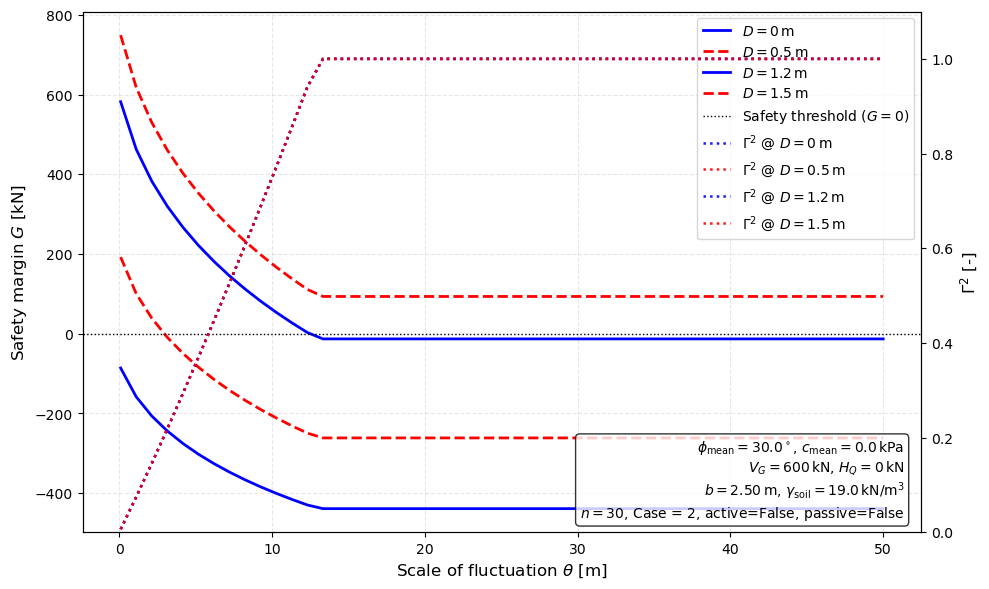

In [4]:
# ==========================================================
# PLOTTING: G vs. θ (left axis) + Γ (right axis) for various D
# ==========================================================
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()  # secondary y-axis for Gamma

# safe cycles in case colors/linestyles are shorter than D_values
color_cycle = itertools.cycle(colors if colors else ["C0", "C1", "C2", "C3"])
ls_cycle    = itertools.cycle(line_styles if line_styles else ["-", "--", ":", "-."])

handles, labels = [], []

# --- Loop over embedment depths ---
for D in D_values:
    color = next(color_cycle)
    ls    = next(ls_cycle)

    G_values = []
    Gamma_values = []   # store Γ = sqrt(gamma_sq)

    for theta in theta_values:
        sol = solve_gamma_phi_fixed_point(
            a=a, b=b, D=D, gamma_soil=gamma_soil,
            phi_mean=phi_mean, c_mean=c_mean, V_G=V_G, H_Q=H_Q,
            phi_cov=phi_cov, phi_theta=float(theta),
            alpha_4017=alpha_4017, beta_4017=beta_4017, Case=Case, n=n,
            use_active=USE_ACTIVE, use_passive=USE_PASSIVE,
            tol=1e-4, itmax=100, foundation=foundation
        )
        G_values.append(sol["G"])
        Gamma_values.append(max(sol["gamma_sq"], 0.0))

    # Plot G (left axis)
    hG, = ax1.plot(
        theta_values, G_values,
        color=color, linestyle=ls, linewidth=2,
        label=rf"$D = {D}\,\mathrm{{m}}$"
    )
    handles.append(hG); labels.append(hG.get_label())

    # Plot Γ (right axis), same color but thinner/dotted
    h2, = ax2.plot(
        theta_values, Gamma_values,
        color=color, linestyle=":", linewidth=1.8, alpha=0.9,
        label=rf"$\Gamma^2$ @ $D={D}\,\mathrm{{m}}$"
    )
    handles.append(h2); labels.append(h2.get_label())

# --- Formatting (axes, grid, legends) ---
ax1.axhline(y=0, color="k", linestyle=":", linewidth=1, label=r"Safety threshold $(G=0)$")
ax1.set_xlabel(r"Scale of fluctuation $\theta$ [m]", fontsize=12)
ax1.set_ylabel(r"Safety margin $G$ [kN]", fontsize=12)
ax2.set_ylabel(r"$\Gamma^2$ [-]", fontsize=12)
ax2.set_ylim(0.0, 1.1)  # Γ is bounded in [0,1]
ax1.grid(True, linestyle="--", alpha=0.3)

# Combine legends from both axes
h0, l0 = ax1.get_legend_handles_labels()
h1, l1 = ax2.get_legend_handles_labels()
leg = ax1.legend(h0 + h1, l0 + l1, loc="best")

# --- Parameter box ---
param_text = (
    rf"$\phi_\mathrm{{mean}} = {phi_mean:.1f}^\circ$, "
    rf"$c_\mathrm{{mean}} = {c_mean:.1f}\,\mathrm{{kPa}}$" + "\n" +
    rf"$V_G = {V_G:.0f}\,\mathrm{{kN}}$, $H_Q = {H_Q:.0f}\,\mathrm{{kN}}$" + "\n" +
    rf"$b = {b:.2f}\,\mathrm{{m}}$, "
    rf"$\gamma_\mathrm{{soil}} = {gamma_soil:.1f}\,\mathrm{{kN/m^3}}$" + "\n" +
    rf"$n = {n}$, Case = {Case}, "
    rf"active={bool(USE_ACTIVE)}, passive={bool(USE_PASSIVE)}"
)
ax1.text(
    0.98, 0.02, param_text, transform=ax1.transAxes,
    ha="right", va="bottom", fontsize=10,
    bbox=dict(facecolor="white", alpha=0.8, boxstyle="round")
)

fig.tight_layout()
plt.show()


In [5]:
# plt.figure(figsize=(10, 6))

# b_values = np.linspace(1, 5, 10)
# theta = 50
# # --- Loop over embedment depths ---
# for D, color, ls in zip(D_values, colors, line_styles):
#     G_values = []
#     for b in b_values:  # loop over b instead of theta
#         res = result(a, b, D, gamma_soil, phi_mean, c_mean, V_G, H_Q,
#                      phi_cov, theta, c_cov, theta,
#                      alpha_4017, beta_4017, Case, n,
#                      use_active=False, use_passive=False)
#         G_values.append(res['G'])
    
#     # Plot the curve for this D
#     plt.plot(b_values, G_values, color=color, linestyle=ls, linewidth=2,
#              label=rf'$D = {D}\,m$')

# # --- Formatting ---
# plt.axhline(y=0, color='k', linestyle=':', linewidth=1, label='Safety threshold ($G=0$)')
# plt.xlabel(r'Foundation width $b$ [m]', fontsize=12)
# plt.ylabel('Safety margin $G$ [kN]', fontsize=12)
# plt.title(r'Safety margin vs. foundation width', fontsize=14)
# plt.grid(True, linestyle='--', alpha=0.3)
# plt.legend(loc='best')

# # --- Parameter box ---
# param_text = (
#     rf"$\phi_\mathrm{{mean}} = {phi_mean}^\circ$, $c_\mathrm{{mean}} = {c_mean}\,kPa$" + "\n" +
#     rf"$V_G = {V_G}\,kN$, $H_Q = {H_Q}\,kN$" + "\n" +
#     rf"$a = {a}\,m$, $\gamma_\mathrm{{soil}} = {gamma_soil}\,kN/m^3$" + "\n" +
#     rf"$n = {n}$, Case = {Case}, $\theta = {theta}\,m$"
# )
# plt.text(0.98, 0.25, param_text, transform=plt.gca().transAxes,
#          ha='right', va='bottom', fontsize=10,
#          bbox=dict(facecolor='white', alpha=0.8, boxstyle='round'))

# plt.tight_layout()
# plt.show()


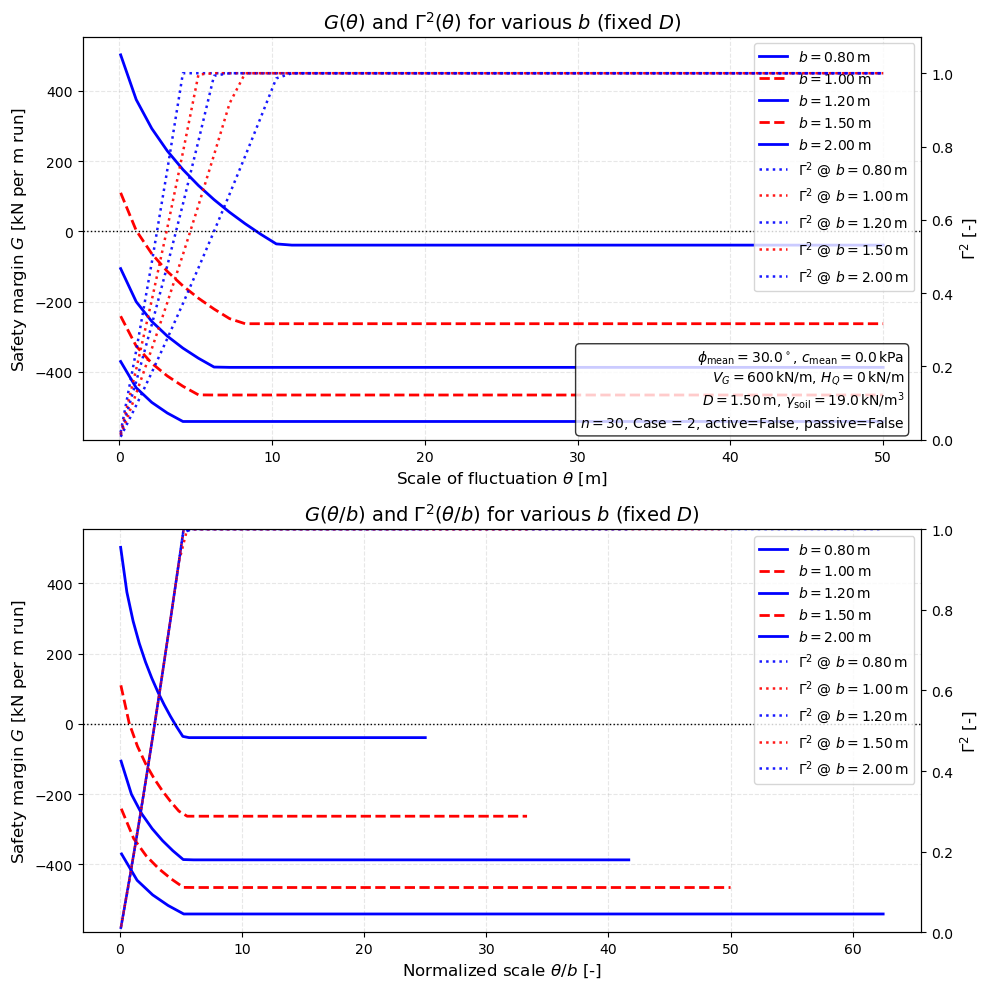

In [ ]:
# widths to compare (you can change this)
B_values = [0.8, 1.0, 1.2, 1.5, 2.0]   # [m]
D_fixed  = D                            # keep your current D

# safe cycles
color_cycle = itertools.cycle(colors if colors else ["C0", "C1", "C2", "C3", "C4"])
ls_cycle    = itertools.cycle(line_styles if line_styles else ["-", "--", ":", "-.", (0,(3,1,1,1))])

# --- helper to call whichever solver you have ---
def _solve_for(b_cur, theta_cur):
    if "solve_gamma_phi_fixed_point_strip" in globals():
        return solve_gamma_phi_fixed_point_strip(
            b=b_cur, D=D_fixed, gamma_soil=gamma_soil,
            phi_mean=phi_mean, c_mean=c_mean, V_G=V_G, H_Q=H_Q,
            phi_cov=phi_cov, phi_theta=float(theta_cur),
            alpha_4017=alpha_4017, beta_4017=beta_4017, Case=Case, n=n,
            use_active=USE_ACTIVE, use_passive=USE_PASSIVE,
            tol=1e-4, itmax=100, c_cov=c_cov, foundation=foundation
        )
    else:
        return solve_gamma_phi_fixed_point(
            a=1.0, b=b_cur, D=D_fixed, gamma_soil=gamma_soil,
            phi_mean=phi_mean, c_mean=c_mean, V_G=V_G, H_Q=H_Q,
            phi_cov=phi_cov, phi_theta=float(theta_cur),
            alpha_4017=alpha_4017, beta_4017=beta_4017, Case=Case, n=n,
            use_active=USE_ACTIVE, use_passive=USE_PASSIVE,
            tol=1e-4, itmax=100, foundation=foundation
        )

# --- precompute for each b ---
curves = []  # list of dicts per b
for b_cur in B_values:
    G_vals, Gam2_vals = [], []
    for theta in theta_values:
        sol = _solve_for(b_cur, theta)
        G_vals.append(sol["G"])
        Gam2_vals.append(max(float(sol["gamma_sq"]), 0.0))
    curves.append({
        "b": b_cur,
        "theta": np.asarray(theta_values, float),
        "theta_over_b": np.asarray(theta_values, float) / float(b_cur),
        "G": np.asarray(G_vals, float),
        "Gam2": np.asarray(Gam2_vals, float),
    })

# ============== PLOT (2 panels: raw θ and normalized θ/b) ==============
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(10, 10), sharey=False)

# ---------- TOP: vs θ ----------
ax_top2 = ax_top.twinx()
color_cycle_top = itertools.cycle(colors if colors else ["C0", "C1", "C2", "C3", "C4"])
ls_cycle_top    = itertools.cycle(line_styles if line_styles else ["-", "--", ":", "-.", (0,(3,1,1,1))])
for c in curves:
    color = next(color_cycle_top)
    ls    = next(ls_cycle_top)
    hG,   = ax_top.plot(c["theta"], c["G"], color=color, ls=ls, lw=2,
                        label=rf"$b={c['b']:.2f}\,\mathrm{{m}}$")
    ax_top2.plot(c["theta"], c["Gam2"], color=color, ls=":", lw=1.8, alpha=0.9,
                 label=rf"$\Gamma^2$ @ $b={c['b']:.2f}\,\mathrm{{m}}$")
ax_top.axhline(0, color="k", ls=":", lw=1)
ax_top.set_xlabel(r"Scale of fluctuation $\theta$ [m]", fontsize=12)
ax_top.set_ylabel(r"Safety margin $G$ [kN per m run]", fontsize=12)
ax_top2.set_ylabel(r"$\Gamma^2$ [-]", fontsize=12)
ax_top2.set_ylim(0.0, 1.1)
ax_top.grid(True, ls="--", alpha=0.3)
h0,l0 = ax_top.get_legend_handles_labels()
h1,l1 = ax_top2.get_legend_handles_labels()
ax_top.legend(h0+h1, l0+l1, loc="best")
ax_top.set_title(r"$G(\theta)$ and $\Gamma^2(\theta)$ for various $b$ (fixed $D$)", fontsize=14)

# ---------- BOTTOM: vs θ/b (normalized) ----------
ax_bot2 = ax_bot.twinx()
color_cycle_bot = itertools.cycle(colors if colors else ["C0", "C1", "C2", "C3", "C4"])
ls_cycle_bot    = itertools.cycle(line_styles if line_styles else ["-", "--", ":", "-.", (0,(3,1,1,1))])
for c in curves:
    color = next(color_cycle_bot)
    ls    = next(ls_cycle_bot)
    xnorm = c["theta_over_b"]
    hG,   = ax_bot.plot(xnorm, c["G"], color=color, ls=ls, lw=2,
                        label=rf"$b={c['b']:.2f}\,\mathrm{{m}}$")
    ax_bot2.plot(xnorm, c["Gam2"], color=color, ls=":", lw=1.8, alpha=0.9,
                 label=rf"$\Gamma^2$ @ $b={c['b']:.2f}\,\mathrm{{m}}$")
ax_bot.axhline(0, color="k", ls=":", lw=1)
ax_bot.set_xlabel(r"Normalized scale $\theta/b$ [-]", fontsize=12)
ax_bot.set_ylabel(r"Safety margin $G$ [kN per m run]", fontsize=12)
ax_bot2.set_ylabel(r"$\Gamma^2$ [-]", fontsize=12)
ax_bot2.set_ylim(0.0, 1.0)
ax_bot.grid(True, ls="--", alpha=0.3)
h0,l0 = ax_bot.get_legend_handles_labels()
h1,l1 = ax_bot2.get_legend_handles_labels()
ax_bot.legend(h0+h1, l0+l1, loc="best")
ax_bot.set_title(r"$G(\theta/b)$ and $\Gamma^2(\theta/b)$ for various $b$ (fixed $D$)", fontsize=14)

# ---------- shared parameter box (put on top axes) ----------
param_text = (
    rf"$\phi_\mathrm{{mean}} = {phi_mean:.1f}^\circ$, "
    rf"$c_\mathrm{{mean}} = {c_mean:.1f}\,\mathrm{{kPa}}$" + "\n" +
    rf"$V_G = {V_G:.0f}\,\mathrm{{kN/m}}$, $H_Q = {H_Q:.0f}\,\mathrm{{kN/m}}$" + "\n" +
    rf"$D = {D_fixed:.2f}\,\mathrm{{m}}$, "
    rf"$\gamma_\mathrm{{soil}} = {gamma_soil:.1f}\,\mathrm{{kN/m^3}}$" + "\n" +
    rf"$n = {n}$, Case = {Case}, "
    rf"active={bool(USE_ACTIVE)}, passive={bool(USE_PASSIVE)}"
)
ax_top.text(
    0.98, 0.02, param_text, transform=ax_top.transAxes,
    ha="right", va="bottom", fontsize=10,
    bbox=dict(facecolor="white", alpha=0.8, boxstyle="round")
)

fig.tight_layout()
plt.show()


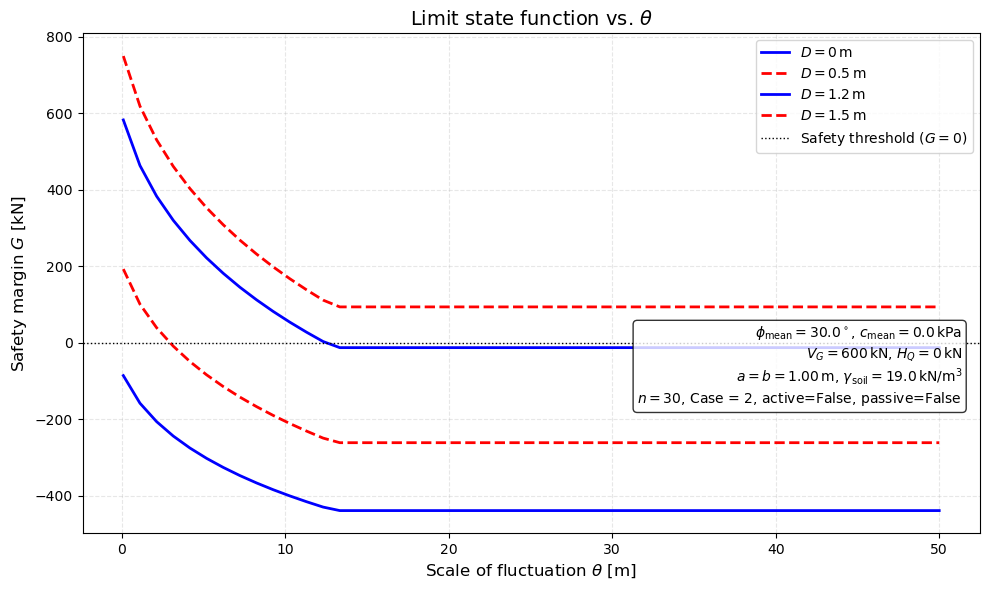

In [6]:
# ==========================================================
# PLOTTING G vs. θ for various D
# ==========================================================
plt.figure(figsize=(10, 6))

# safe cycles in case colors/linestyles are shorter than D_values
color_cycle = itertools.cycle(colors if colors else ["C0", "C1", "C2", "C3"])
ls_cycle    = itertools.cycle(line_styles if line_styles else ["-", "--", ":", "-."])

# --- Loop over embedment depths ---
for D in D_values:
    color = next(color_cycle)
    ls    = next(ls_cycle)

    G_values = []
    for theta in theta_values:
        # θ here is the scale of fluctuation for φ (phi_theta)
        sol = solve_gamma_phi_fixed_point(
            a=a, b=b, D=D, gamma_soil=gamma_soil,
            phi_mean=phi_mean, c_mean=c_mean, V_G=V_G, H_Q=H_Q,
            phi_cov=phi_cov, phi_theta=float(theta),   # <-- vary θ here
            alpha_4017=alpha_4017, beta_4017=beta_4017, Case=Case, n=n,
            use_active=USE_ACTIVE, use_passive=USE_PASSIVE,
            tol=1e-4, itmax=100
        )
        G_values.append(sol["G"])

    # Plot the curve for this D
    plt.plot(
        theta_values, G_values,
        color=color, linestyle=ls, linewidth=2,
        label=rf"$D = {D}\,\mathrm{{m}}$"
    )

# --- Formatting ---
plt.axhline(y=0, color="k", linestyle=":", linewidth=1, label=r"Safety threshold $(G=0)$")
plt.xlabel(r"Scale of fluctuation $\theta$ [m]", fontsize=12)
plt.ylabel(r"Safety margin $G$ [kN]", fontsize=12)
plt.title(r"Limit state function vs. $\theta$", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend(loc="best")

# --- Parameter box ---
param_text = (
    rf"$\phi_\mathrm{{mean}} = {phi_mean:.1f}^\circ$, "
    rf"$c_\mathrm{{mean}} = {c_mean:.1f}\,\mathrm{{kPa}}$" + "\n" +
    rf"$V_G = {V_G:.0f}\,\mathrm{{kN}}$, $H_Q = {H_Q:.0f}\,\mathrm{{kN}}$" + "\n" +
    rf"$a = b = {a:.2f}\,\mathrm{{m}}$, "
    rf"$\gamma_\mathrm{{soil}} = {gamma_soil:.1f}\,\mathrm{{kN/m^3}}$" + "\n" +
    rf"$n = {n}$, Case = {Case}, "
    rf"active={bool(USE_ACTIVE)}, passive={bool(USE_PASSIVE)}"
)
plt.text(
    0.98, 0.25, param_text, transform=plt.gca().transAxes,
    ha="right", va="bottom", fontsize=10,
    bbox=dict(facecolor="white", alpha=0.8, boxstyle="round")
)

plt.tight_layout()
plt.show()